<a href="https://colab.research.google.com/github/omarcordero1/-omarcordero1/blob/main/Emociones_redes_sociales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análisis de Emociones para redes sociales**:

In [ ]:
!pip install pandas openpyxl transformers torch spacy nltk textblob wordcloud matplotlib seaborn plotly scikit-learn emoji unidecode -q
!python -m spacy download es_core_news_md -q
!python -m nltk.downloader punkt stopwords vader_lexicon -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 6.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour


In [ ]:
import pandas as pd
import numpy as np
import re
import emoji
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# NLP
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

# Transformers para análisis de sentimientos en español
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [ ]:
# Cargar modelo de español de spaCy
nlp = spacy.load('es_core_news_md')

# Stopwords en español
nltk.download('stopwords', quiet=True)
stop_words_es = set(stopwords.words('spanish'))
# Añadir stopwords personalizadas para redes sociales
stop_words_custom = {'https', 'http', 'co', 'rt', 'via', 'jaja', 'jajaja', 'xd',
                     'si', 'no', 'ya', 'hoy', 'día', 'solo', 'aquí', 'así'}
stop_words_es.update(stop_words_custom)

# Subir archivo desde Google Colab
from google.colab import files
print("📁 Sube tu archivo Excel (Cuentas.xlsx):")
uploaded = files.upload()

# Cargar el DataFrame
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
print(f"\n✅ Archivo cargado: {file_name}")
print(f"📊 Total de registros: {len(df)}")
print(f"📋 Columnas: {list(df.columns)}")

📁 Sube tu archivo Excel (Cuentas.xlsx):


Saving Cuentas.xlsx to Cuentas (2).xlsx

✅ Archivo cargado: Cuentas (2).xlsx
📊 Total de registros: 100
📋 Columnas: ['ID', 'Fecha', 'Hora', 'Plataforma', 'Usuario/Autor', 'Tipo de contenido', 'Mención / Texto', 'URL', 'Vistas', 'Likes', 'Comentarios', 'Compartidos', 'Interacciones totales', 'Sentimiento', 'Equipo mencionado', 'Etiquetas / Hashtags', '¿Es oficial?', 'Notas adicionales']


In [ ]:
class TextPreprocessor:
    """Clase para preprocesamiento de texto en español"""

    def __init__(self):
        self.url_pattern = re.compile(r'https?://\S+|www\.\S+')
        self.mention_pattern = re.compile(r'@\w+')
        self.hashtag_pattern = re.compile(r'#\w+')
        self.emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)

    def extract_emojis(self, text):
        """Extrae emojis del texto"""
        return emoji.emoji_list(str(text))

    def extract_hashtags(self, text):
        """Extrae hashtags"""
        return self.hashtag_pattern.findall(str(text))

    def extract_mentions(self, text):
        """Extrae menciones"""
        return self.mention_pattern.findall(str(text))

    def clean_text(self, text):
        """Limpia el texto para análisis"""
        if pd.isna(text):
            return ""
        text = str(text).lower()
        text = self.url_pattern.sub('', text)
        text = self.mention_pattern.sub('', text)
        text = self.hashtag_pattern.sub('', text)
        text = self.emoji_pattern.sub('', text)
        text = re.sub(r'[^\w\sáéíóúüñ]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def get_tokens(self, text):
        """Tokeniza y elimina stopwords"""
        clean = self.clean_text(text)
        tokens = clean.split()
        return [t for t in tokens if t not in stop_words_es and len(t) > 2]

preprocessor = TextPreprocessor()

# Aplicar preprocesamiento
df['texto_limpio'] = df['Mención / Texto'].apply(preprocessor.clean_text)
df['tokens'] = df['Mención / Texto'].apply(preprocessor.get_tokens)
df['emojis'] = df['Mención / Texto'].apply(preprocessor.extract_emojis)
df['hashtags_extraidos'] = df['Mención / Texto'].apply(preprocessor.extract_hashtags)
df['menciones_extraidas'] = df['Mención / Texto'].apply(preprocessor.extract_mentions)
df['num_palabras'] = df['tokens'].apply(len)
df['num_emojis'] = df['emojis'].apply(len)

print("✅ Preprocesamiento completado")

✅ Preprocesamiento completado


ANÁLISIS DE EMOCIONES (MODELO PLUTCHIK)

In [ ]:
class EmotionAnalyzer:
    """
    Clasificador de emociones basado en el modelo de Plutchik
    Emociones: Enojo, Precaución, Disgusto, Miedo, Alegría, Tristeza, Sorpresa, Confianza
    """

    def __init__(self):
        # Diccionario de palabras clave para cada emoción (español mexicano)
        self.emotion_lexicon = {
            'Alegría': {
                'palabras': ['feliz', 'alegre', 'contento', 'genial', 'increíble', 'maravilloso',
                            'victoria', 'ganar', 'ganamos', 'campeón', 'campeonato', 'fiesta',
                            'celebrar', 'golazo', 'crack', 'ídolo', 'orgullo', 'vamos',
                            'grande', 'mejor', 'arriba', 'éxito', 'triunfo', 'gloria',
                            'histórico', 'épico', 'brutal', 'chingón', 'rifado'],
                'emojis': ['😀', '😁', '😂', '🤣', '😃', '😄', '😅', '😆', '🥳', '🎉',
                          '🎊', '🏆', '🥇', '💪', '🔥', '⚽', '🦅', '💙', '💛'],
                'peso': 1.0
            },
            'Enojo': {
                'palabras': ['enojado', 'furioso', 'molesto', 'rabia', 'coraje', 'odio',
                            'mal', 'pésimo', 'vergüenza', 'fracaso', 'fraude', 'robo',
                            'árbitro', 'injusto', 'tramposo', 'penal', 'ladrón', 'rata',
                            'vendido', 'corrupto', 'asco', 'maldito', 'pinche', 'chingar'],
                'emojis': ['😠', '😡', '🤬', '💢', '👎', '🖕'],
                'peso': 1.2
            },
            'Tristeza': {
                'palabras': ['triste', 'llorar', 'perdimos', 'derrota', 'eliminados',
                            'decepción', 'dolor', 'sufrir', 'pena', 'lástima', 'mal',
                            'acabó', 'terminó', 'adiós', 'despedida', 'cayó', 'caímos'],
                'emojis': ['😢', '😭', '😿', '💔', '😞', '😔', '😥'],
                'peso': 1.0
            },
            'Miedo': {
                'palabras': ['miedo', 'terror', 'pánico', 'nervios', 'preocupado',
                            'asustado', 'peligro', 'riesgo', 'cuidado', 'temblar',
                            'tenso', 'angustia', 'ansiedad', 'susto'],
                'emojis': ['😨', '😰', '😱', '🫣', '😬'],
                'peso': 0.9
            },
            'Sorpresa': {
                'palabras': ['sorpresa', 'increíble', 'impresionante', 'inesperado',
                            'wow', 'guau', 'órale', 'neta', 'noches', 'histórico',
                            'nunca', 'primera', 'jamás', 'épico', 'locura'],
                'emojis': ['😮', '😲', '🤯', '😳', '🫢', '❗', '‼️', '⁉️'],
                'peso': 0.8
            },
            'Confianza': {
                'palabras': ['confianza', 'seguro', 'confío', 'creo', 'vamos',
                            'podemos', 'lograremos', 'fuerte', 'equipo', 'unidos',
                            'juntos', 'familia', 'lealtad', 'fiel', 'apoyo',
                            'siempre', 'incondicional', 'aguante'],
                'emojis': ['💪', '🤝', '🦅', '💙', '💛', '❤️', '🙌'],
                'peso': 1.0
            },
            'Disgusto': {
                'palabras': ['asco', 'repugnante', 'asqueroso', 'horrible', 'feo',
                            'patético', 'ridículo', 'penoso', 'lamentable', 'basura',
                            'porquería', 'mediocre', 'decadente'],
                'emojis': ['🤢', '🤮', '😖', '💩'],
                'peso': 1.1
            },
            'Precaución': {
                'palabras': ['cuidado', 'ojo', 'atención', 'alerta', 'advertencia',
                            'precaución', 'calma', 'tranquilo', 'esperar', 'paciencia',
                            'analizar', 'pensar', 'revisar', 'vigilar'],
                'emojis': ['⚠️', '🚨', '👀', '🧐', '🤔'],
                'peso': 0.7
            }
        }

        # Cargar modelo de sentimiento en español (HuggingFace)
        try:
            self.sentiment_pipeline = pipeline(
                "sentiment-analysis",
                model="nlptown/bert-base-multilingual-uncased-sentiment",
                tokenizer="nlptown/bert-base-multilingual-uncased-sentiment"
            )
            self.use_transformer = True
            print("✅ Modelo de sentimientos cargado (BERT multilingual)")
        except Exception as e:
            print(f"⚠️ No se pudo cargar BERT, usando análisis basado en léxico: {e}")
            self.use_transformer = False

    def analyze_emotions(self, text):
        """Analiza emociones en un texto"""
        if pd.isna(text) or text == "":
            return {'emocion_principal': 'Neutral', 'emociones_detectadas': {},
                    'intensidad': 0, 'sentimiento_general': 'Neutral'}

        text_lower = str(text).lower()
        text_emojis = emoji.emoji_list(str(text))
        emoji_chars = [e['emoji'] for e in text_emojis]

        emotion_scores = {}

        for emotion, data in self.emotion_lexicon.items():
            score = 0
            # Contar palabras clave
            for palabra in data['palabras']:
                if palabra in text_lower:
                    score += 1 * data['peso']
            # Contar emojis
            for em in data['emojis']:
                if em in emoji_chars:
                    score += 0.5 * data['peso']

            emotion_scores[emotion] = round(score, 2)

        # Determinar emoción principal
        if max(emotion_scores.values()) > 0:
            emocion_principal = max(emotion_scores, key=emotion_scores.get)
            intensidad = min(emotion_scores[emocion_principal] / 3, 1.0)
        else:
            emocion_principal = 'Neutral'
            intensidad = 0

        # Sentimiento general (usando transformer si está disponible)
        if self.use_transformer and len(text) > 10:
            try:
                result = self.sentiment_pipeline(text[:512])[0]
                stars = int(result['label'].split()[0])
                if stars >= 4:
                    sentimiento = 'Positivo'
                elif stars <= 2:
                    sentimiento = 'Negativo'
                else:
                    sentimiento = 'Neutral'
            except:
                sentimiento = self._get_sentiment_from_emotions(emotion_scores)
        else:
            sentimiento = self._get_sentiment_from_emotions(emotion_scores)

        return {
            'emocion_principal': emocion_principal,
            'emociones_detectadas': emotion_scores,
            'intensidad': round(intensidad, 2),
            'sentimiento_general': sentimiento
        }

    def _get_sentiment_from_emotions(self, scores):
        """Deriva sentimiento de las emociones"""
        positivas = scores.get('Alegría', 0) + scores.get('Confianza', 0) + scores.get('Sorpresa', 0) * 0.5
        negativas = scores.get('Enojo', 0) + scores.get('Tristeza', 0) + scores.get('Miedo', 0) + scores.get('Disgusto', 0)

        if positivas > negativas + 0.5:
            return 'Positivo'
        elif negativas > positivas + 0.5:
            return 'Negativo'
        return 'Neutral'

# Instanciar analizador
emotion_analyzer = EmotionAnalyzer()

# Aplicar análisis de emociones
print("\n🔄 Analizando emociones (esto puede tardar unos minutos)...")
emotion_results = df['Mención / Texto'].apply(emotion_analyzer.analyze_emotions)

df['emocion_principal'] = emotion_results.apply(lambda x: x['emocion_principal'])
df['intensidad_emocional'] = emotion_results.apply(lambda x: x['intensidad'])
df['sentimiento_analizado'] = emotion_results.apply(lambda x: x['sentimiento_general'])
df['emociones_todas'] = emotion_results.apply(lambda x: x['emociones_detectadas'])

print("✅ Análisis de emociones completado")

Device set to use cpu


✅ Modelo de sentimientos cargado (BERT multilingual)

🔄 Analizando emociones (esto puede tardar unos minutos)...
✅ Análisis de emociones completado


Identificamos temas

In [ ]:
class TopicAnalyzer:
    """Análisis de temas usando LDA y clustering"""

    def __init__(self, n_topics=5):
        self.n_topics = n_topics
        self.vectorizer = CountVectorizer(
            max_features=1000,
            stop_words=list(stop_words_es),
            min_df=2,
            max_df=0.95
        )
        self.lda_model = LatentDirichletAllocation(
            n_components=n_topics,
            random_state=42,
            max_iter=10
        )
        self.tfidf = TfidfVectorizer(
            max_features=500,
            stop_words=list(stop_words_es)
        )

    def fit_transform(self, texts):
        """Entrena el modelo y extrae temas"""
        clean_texts = [t for t in texts if len(str(t)) > 10]

        # LDA
        dtm = self.vectorizer.fit_transform(clean_texts)
        self.lda_model.fit(dtm)

        # Obtener palabras clave por tema
        feature_names = self.vectorizer.get_feature_names_out()
        topics = {}

        for idx, topic in enumerate(self.lda_model.components_):
            top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
            topic_name = self._generate_topic_name(top_words)
            topics[f"Tema_{idx+1}"] = {
                'nombre': topic_name,
                'palabras_clave': top_words,
                'peso': topic.sum()
            }

        return topics

    def predict_topic(self, text):
        """Predice el tema de un texto"""
        if len(str(text)) < 10:
            return "Sin clasificar"
        try:
            vec = self.vectorizer.transform([str(text)])
            topic_dist = self.lda_model.transform(vec)[0]
            return f"Tema_{np.argmax(topic_dist) + 1}"
        except:
            return "Sin clasificar"

    def _generate_topic_name(self, words):
        """Genera nombre descriptivo para el tema"""
        topic_keywords = {
            'partido': 'Análisis del Partido',
            'gol': 'Goles y Jugadas',
            'equipo': 'Equipo y Plantilla',
            'afición': 'Afición y Apoyo',
            'estadio': 'Estadio y Ambiente',
            'jugador': 'Jugadores Destacados',
            'táctica': 'Análisis Táctico',
            'meme': 'Memes y Humor',
            'historia': 'Historia y Rivalidad'
        }

        for word in words[:5]:
            for key, name in topic_keywords.items():
                if key in word:
                    return name

        return f"Tema: {', '.join(words[:3])}"

# Aplicar análisis de temas
topic_analyzer = TopicAnalyzer(n_topics=5)
topics_info = topic_analyzer.fit_transform(df['texto_limpio'])

df['tema_asignado'] = df['texto_limpio'].apply(topic_analyzer.predict_topic)

print("\n📊 TEMAS IDENTIFICADOS:")
for tema_id, info in topics_info.items():
    print(f"\n{tema_id}: {info['nombre']}")
    print(f"   Palabras clave: {', '.join(info['palabras_clave'][:7])}")


📊 TEMAS IDENTIFICADOS:

Tema_1: Tema: henry, trick, hat
   Palabras clave: henry, trick, hat, clásico, azteca, goles, américa

Tema_2: Tema: gloria, clave, fans
   Palabras clave: gloria, clave, fans, corazón, orgullo, nacional, azteca

Tema_3: Goles y Jugadas
   Palabras clave: henry, américa, guido, leyenda, goles, gracias, historia

Tema_4: Tema: henry, azteca, chivas
   Palabras clave: henry, azteca, chivas, américa, min, festejo, martín

Tema_5: Tema: américa, clásico, súper
   Palabras clave: américa, clásico, súper, chivas, mena, azteca, penal


EXTRACCIÓN DE ENTIDADES Y PERSONAJES

In [ ]:
class EntityExtractor:
    """Extractor de entidades nombradas (jugadores, equipos, lugares)"""

    def __init__(self):
        # Diccionario de entidades conocidas
        self.known_entities = {
            'jugadores_america': ['henry martín', 'martín', 'henry', 'guido rodríguez', 'guido',
                                  'richard sánchez', 'marchesín', 'córdova', 'fidalgo',
                                  'diego valdés', 'valdés', 'kevin álvarez', 'reyes'],
            'jugadores_chivas': ['pulido', 'alan mozo', 'mozo', 'chicote', 'calderón',
                                'piojo alvarado', 'chofis', 'vega', 'cisneros'],
            'equipos': ['américa', 'chivas', 'águilas', 'rebaño', 'guadalajara',
                       'azulcremas', 'rojiblancos'],
            'lugares': ['azteca', 'estadio azteca', 'akron', 'cdmx', 'guadalajara'],
            'medios': ['espn', 'tudn', 'fox sports', 'azteca deportes', 'mediotiempo']
        }

    def extract_entities(self, text):
        """Extrae entidades del texto"""
        if pd.isna(text):
            return {'personas': [], 'equipos': [], 'lugares': [], 'organizaciones': []}

        text_lower = str(text).lower()
        doc = nlp(str(text)[:1000])  # Limitar tamaño

        entities = {
            'personas': [],
            'equipos': [],
            'lugares': [],
            'organizaciones': []
        }

        # Usar spaCy NER
        for ent in doc.ents:
            if ent.label_ == 'PER':
                entities['personas'].append(ent.text)
            elif ent.label_ == 'LOC':
                entities['lugares'].append(ent.text)
            elif ent.label_ == 'ORG':
                entities['organizaciones'].append(ent.text)

        # Buscar entidades conocidas
        for jugador in self.known_entities['jugadores_america'] + self.known_entities['jugadores_chivas']:
            if jugador in text_lower:
                if jugador not in [p.lower() for p in entities['personas']]:
                    entities['personas'].append(jugador.title())

        for equipo in self.known_entities['equipos']:
            if equipo in text_lower:
                entities['equipos'].append(equipo.title())

        return entities

    def get_main_character(self, entities):
        """Determina el personaje principal"""
        if entities['personas']:
            return entities['personas'][0]
        elif entities['equipos']:
            return entities['equipos'][0]
        return None

entity_extractor = EntityExtractor()

# Aplicar extracción de entidades
df['entidades'] = df['Mención / Texto'].apply(entity_extractor.extract_entities)
df['personaje_principal'] = df['entidades'].apply(entity_extractor.get_main_character)

print("\n✅ Extracción de entidades completada")


✅ Extracción de entidades completada


DETECCIÓN DE COMUNICACIÓN REPETIDA (POSIBLES BOTS)

In [ ]:
class BotDetector:
    """Detector de patrones de comunicación automatizada/bots"""

    def __init__(self, df):
        self.df = df

    def detect_repeated_content(self, threshold=0.85):
        """Detecta contenido repetido o muy similar"""
        from sklearn.metrics.pairwise import cosine_similarity

        texts = self.df['texto_limpio'].fillna('').tolist()

        # TF-IDF para similitud
        tfidf = TfidfVectorizer(min_df=1, max_features=500)
        try:
            tfidf_matrix = tfidf.fit_transform(texts)
            similarity_matrix = cosine_similarity(tfidf_matrix)
        except:
            return pd.DataFrame()

        # Encontrar pares similares
        duplicates = []
        for i in range(len(similarity_matrix)):
            for j in range(i+1, len(similarity_matrix)):
                if similarity_matrix[i][j] >= threshold:
                    duplicates.append({
                        'indice_1': i,
                        'indice_2': j,
                        'similitud': round(similarity_matrix[i][j], 3),
                        'usuario_1': self.df.iloc[i]['Usuario/Autor'],
                        'usuario_2': self.df.iloc[j]['Usuario/Autor'],
                        'texto_1': str(self.df.iloc[i]['Mención / Texto'])[:100],
                        'texto_2': str(self.df.iloc[j]['Mención / Texto'])[:100]
                    })

        return pd.DataFrame(duplicates)

    def detect_bot_patterns(self):
        """Detecta patrones típicos de bots"""
        bot_indicators = []

        for idx, row in self.df.iterrows():
            score = 0
            reasons = []

            text = str(row['Mención / Texto'])

            # Indicador 1: Texto muy corto con muchos hashtags
            hashtags = len(re.findall(r'#\w+', text))
            words = len(text.split())
            if hashtags > 3 and words < 15:
                score += 2
                reasons.append("Muchos hashtags, poco texto")

            # Indicador 2: Solo enlaces
            if re.match(r'^https?://\S+$', text.strip()):
                score += 3
                reasons.append("Solo contiene enlace")

            # Indicador 3: Patrones de publicación (mismo usuario, múltiples posts)
            user_posts = len(self.df[self.df['Usuario/Autor'] == row['Usuario/Autor']])
            if user_posts > 5:
                score += 1
                reasons.append(f"Usuario muy activo ({user_posts} posts)")

            # Indicador 4: Texto genérico/template
            generic_patterns = [
                r'¡?vamos\s+\w+!?$',
                r'^#\w+\s*#\w+\s*#\w+$',
                r'síguenos|follow|rt si'
            ]
            for pattern in generic_patterns:
                if re.search(pattern, text.lower()):
                    score += 1
                    reasons.append("Patrón genérico detectado")
                    break

            bot_indicators.append({
                'indice': idx,
                'usuario': row['Usuario/Autor'],
                'bot_score': score,
                'es_posible_bot': score >= 3,
                'razones': '; '.join(reasons) if reasons else 'Ninguna'
            })

        return pd.DataFrame(bot_indicators)

bot_detector = BotDetector(df)

# Detectar contenido repetido
print("\n🔍 Detectando contenido repetido...")
contenido_repetido = bot_detector.detect_repeated_content(threshold=0.80)

# Detectar patrones de bots
print("🤖 Analizando patrones de bots...")
bot_analysis = bot_detector.detect_bot_patterns()
df['bot_score'] = bot_analysis['bot_score'].values
df['posible_bot'] = bot_analysis['es_posible_bot'].values

posibles_bots = df[df['posible_bot'] == True]
print(f"\n⚠️ Posibles cuentas automatizadas detectadas: {len(posibles_bots)}")


🔍 Detectando contenido repetido...
🤖 Analizando patrones de bots...

⚠️ Posibles cuentas automatizadas detectadas: 0


IDENTIFICACIÓN DE INFLUENCIADORES

In [ ]:
class InfluencerAnalyzer:
    """Analizador de influencia y engagement"""

    def __init__(self, df):
        self.df = df

    def calculate_influence_score(self):
        """Calcula score de influencia para cada usuario"""
        # Convertir métricas a numérico
        metrics = ['Vistas', 'Likes', 'Comentarios', 'Compartidos', 'Interacciones totales']
        for col in metrics:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce').fillna(0)

        # Agrupar por usuario
        user_stats = self.df.groupby('Usuario/Autor').agg({
            'Vistas': 'sum',
            'Likes': 'sum',
            'Comentarios': 'sum',
            'Compartidos': 'sum',
            'Interacciones totales': 'sum',
            'ID': 'count'
        }).rename(columns={'ID': 'num_posts'})

        # Calcular score de influencia
        user_stats['engagement_rate'] = (
            (user_stats['Likes'] + user_stats['Comentarios'] * 2 + user_stats['Compartidos'] * 3) /
            (user_stats['Vistas'].replace(0, 1))
        ) * 100

        # Score compuesto
        user_stats['influence_score'] = (
            np.log1p(user_stats['Vistas']) * 0.3 +
            np.log1p(user_stats['Likes']) * 0.25 +
            np.log1p(user_stats['Comentarios']) * 0.2 +
            np.log1p(user_stats['Compartidos']) * 0.25
        )

        # Normalizar 0-100
        max_score = user_stats['influence_score'].max()
        if max_score > 0:
            user_stats['influence_score_normalized'] = (
                user_stats['influence_score'] / max_score * 100
            ).round(1)
        else:
            user_stats['influence_score_normalized'] = 0

        # Clasificar tipo de influenciador
        def classify_influencer(row):
            if row['influence_score_normalized'] >= 80:
                return 'Mega Influencer'
            elif row['influence_score_normalized'] >= 60:
                return 'Macro Influencer'
            elif row['influence_score_normalized'] >= 40:
                return 'Mid-tier Influencer'
            elif row['influence_score_normalized'] >= 20:
                return 'Micro Influencer'
            else:
                return 'Usuario Regular'

        user_stats['categoria_influencer'] = user_stats.apply(classify_influencer, axis=1)

        return user_stats.sort_values('influence_score_normalized', ascending=False)

influencer_analyzer = InfluencerAnalyzer(df)
influencer_ranking = influencer_analyzer.calculate_influence_score()

print("\n🌟 TOP 10 INFLUENCIADORES:")
print(influencer_ranking[['Vistas', 'Likes', 'engagement_rate', 'influence_score_normalized', 'categoria_influencer']].head(10))


🌟 TOP 10 INFLUENCIADORES:
                          Vistas      Likes  engagement_rate  \
Usuario/Autor                                                  
@MemesAguilas         15357000.0  1207000.0     1.614951e+01   
america.oficial        2120000.0   717900.0     3.071703e+02   
@CronicasAguilas      10900000.0   853100.0     1.649761e+01   
#VamosAmérica          3700000.0   275200.0     2.348649e+01   
@FanaticaAguila         420000.0   118800.0     4.504762e+01   
Reflejo Deportivo       919600.0    41470.0     1.214996e+01   
Orgullo Americanista    420000.0    61490.0     2.605119e+01   
Entrenador en Jefe      445500.0    27460.0     1.655443e+01   
Fútbol Mexicano HD      187600.0    12450.0     1.856077e+01   
@Henry_Martin19              0.0   975200.0     5.536560e+08   

                      influence_score_normalized categoria_influencer  
Usuario/Autor                                                          
@MemesAguilas                              100.0      Mega I

**Visualizaciones**


📊 Generando visualizaciones...


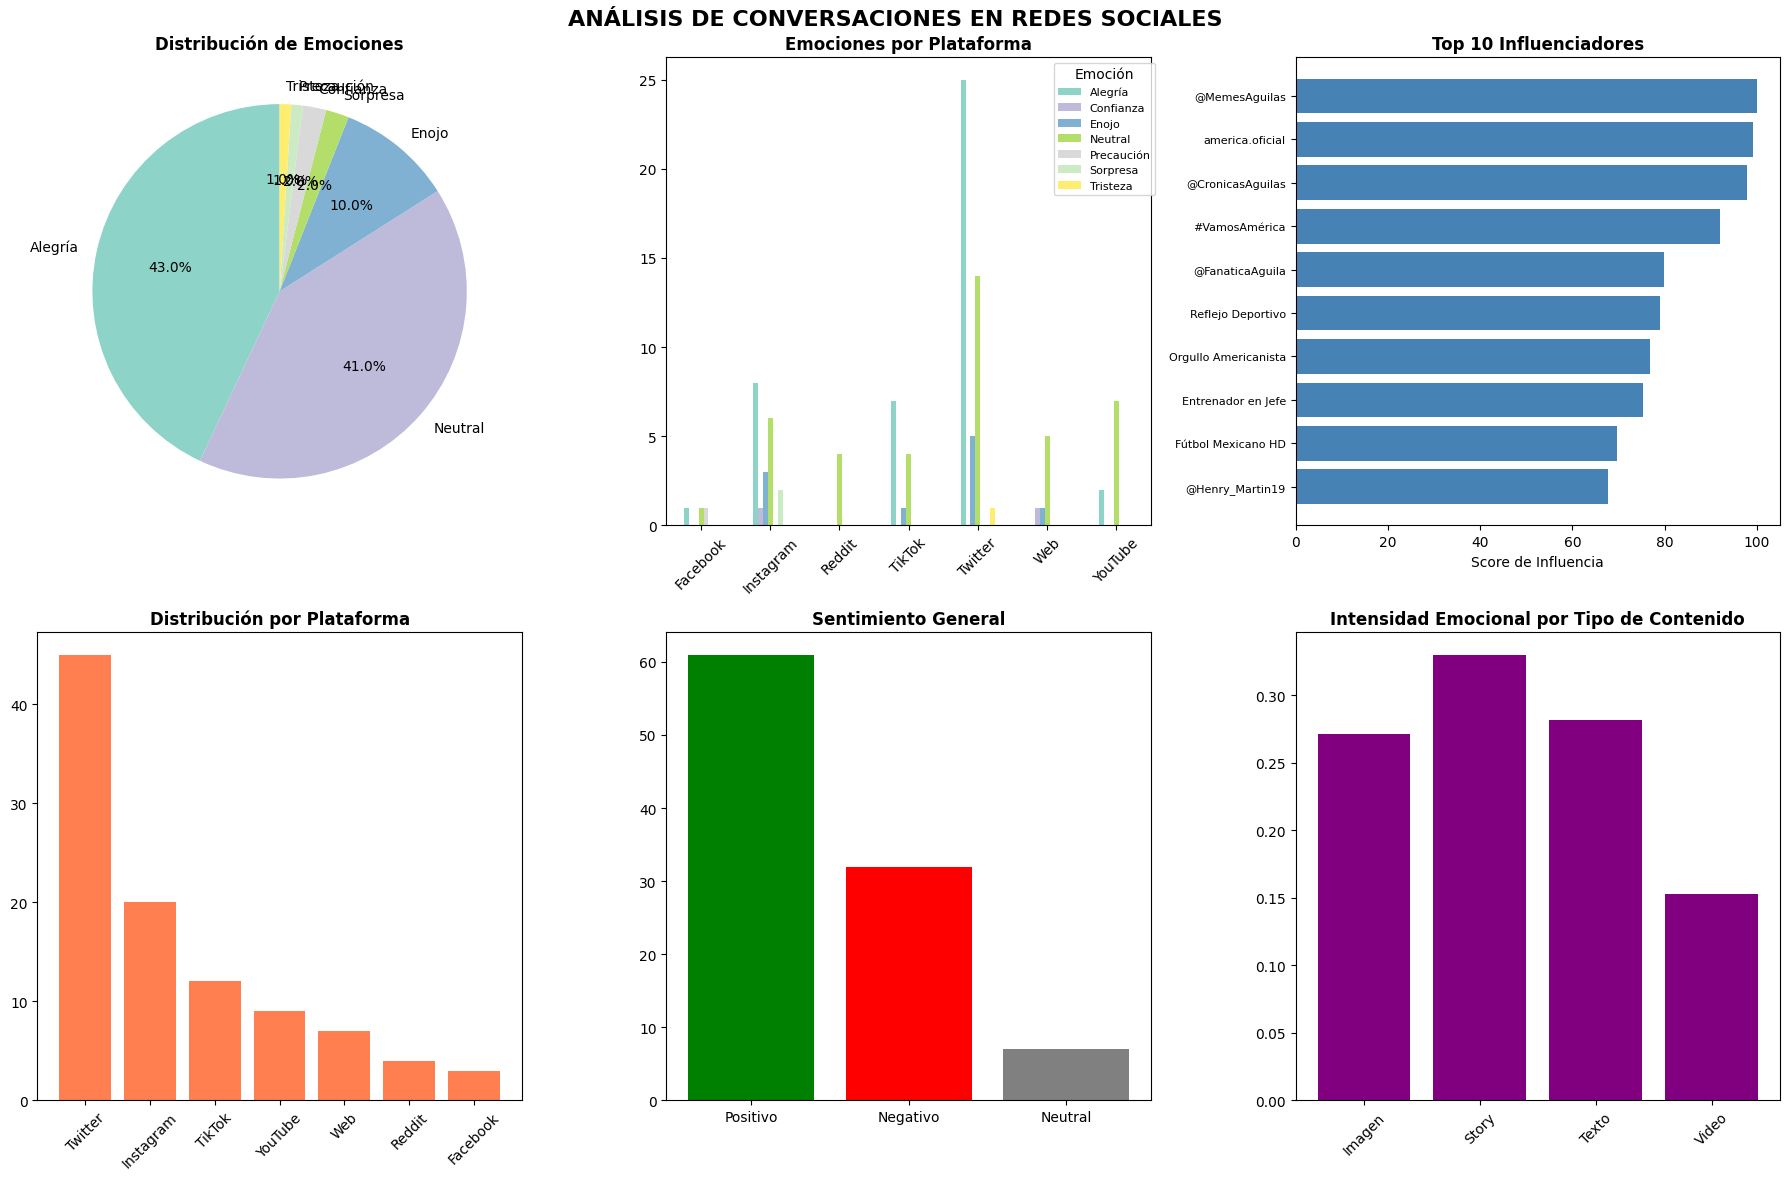

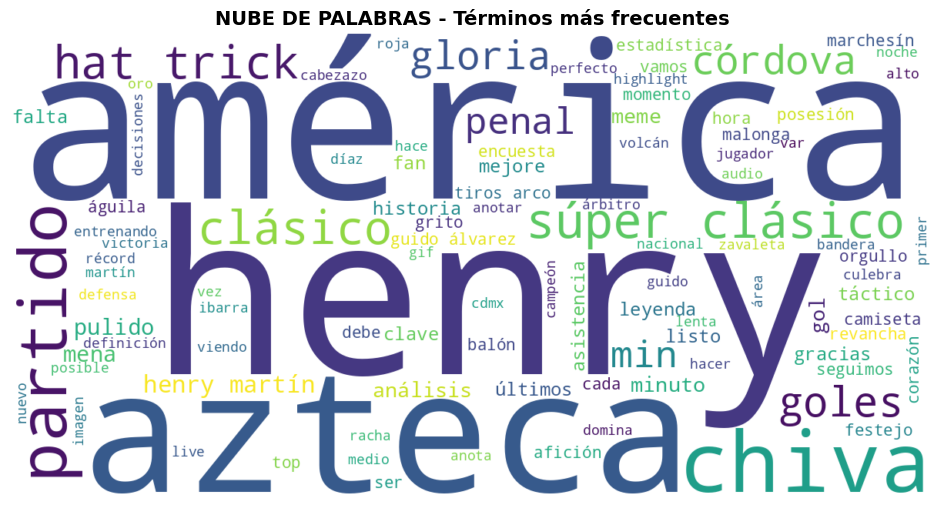

In [ ]:
def create_visualizations(df, influencer_ranking, topics_info):
    """Genera visualizaciones del análisis"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('ANÁLISIS DE CONVERSACIONES EN REDES SOCIALES', fontsize=16, fontweight='bold')

    # 1. Distribución de Emociones
    ax1 = axes[0, 0]
    emotion_counts = df['emocion_principal'].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(emotion_counts)))
    ax1.pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
    ax1.set_title('Distribución de Emociones', fontweight='bold')

    # 2. Emociones por Plataforma
    ax2 = axes[0, 1]
    emotion_platform = pd.crosstab(df['Plataforma'], df['emocion_principal'])
    emotion_platform.plot(kind='bar', ax=ax2, colormap='Set3')
    ax2.set_title('Emociones por Plataforma', fontweight='bold')
    ax2.set_xlabel('')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Emoción', bbox_to_anchor=(1.02, 1), fontsize=8)

    # 3. Top Influenciadores
    ax3 = axes[0, 2]
    top_inf = influencer_ranking.head(10)
    y_pos = np.arange(len(top_inf))
    ax3.barh(y_pos, top_inf['influence_score_normalized'], color='steelblue')
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels([str(name)[:20] for name in top_inf.index], fontsize=8)
    ax3.set_xlabel('Score de Influencia')
    ax3.set_title('Top 10 Influenciadores', fontweight='bold')
    ax3.invert_yaxis()

    # 4. Distribución por Plataforma
    ax4 = axes[1, 0]
    platform_counts = df['Plataforma'].value_counts()
    ax4.bar(platform_counts.index, platform_counts.values, color='coral')
    ax4.set_title('Distribución por Plataforma', fontweight='bold')
    ax4.tick_params(axis='x', rotation=45)

    # 5. Sentimiento General
    ax5 = axes[1, 1]
    sentiment_counts = df['sentimiento_analizado'].value_counts()
    colors_sent = {'Positivo': 'green', 'Negativo': 'red', 'Neutral': 'gray'}
    ax5.bar(sentiment_counts.index, sentiment_counts.values,
            color=[colors_sent.get(x, 'blue') for x in sentiment_counts.index])
    ax5.set_title('Sentimiento General', fontweight='bold')

    # 6. Intensidad Emocional por Tipo de Contenido
    ax6 = axes[1, 2]
    intensity_by_type = df.groupby('Tipo de contenido')['intensidad_emocional'].mean()
    ax6.bar(intensity_by_type.index, intensity_by_type.values, color='purple')
    ax6.set_title('Intensidad Emocional por Tipo de Contenido', fontweight='bold')
    ax6.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('analisis_conversaciones.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Nube de palabras
    plt.figure(figsize=(12, 6))
    all_tokens = ' '.join([' '.join(t) for t in df['tokens'] if t])
    if all_tokens:
        wordcloud = WordCloud(
            width=1200, height=600,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(all_tokens)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('NUBE DE PALABRAS - Términos más frecuentes', fontsize=14, fontweight='bold')
        plt.savefig('nube_palabras.png', dpi=150, bbox_inches='tight')
        plt.show()

print("\n📊 Generando visualizaciones...")
create_visualizations(df, influencer_ranking, topics_info)


**Generación del reporte**

In [ ]:
def generate_report(df, influencer_ranking, topics_info, contenido_repetido):
    """Genera reporte completo del análisis"""

    report = []
    report.append("=" * 80)
    report.append("REPORTE DE ANÁLISIS DE CONVERSACIONES EN REDES SOCIALES")
    report.append("=" * 80)
    report.append(f"\nFecha de análisis: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
    report.append(f"Total de registros analizados: {len(df)}")

    # Resumen de Emociones
    report.append("\n" + "=" * 40)
    report.append("📊 ANÁLISIS DE EMOCIONES")
    report.append("=" * 40)
    emotion_summary = df['emocion_principal'].value_counts()
    for emotion, count in emotion_summary.items():
        pct = count / len(df) * 100
        report.append(f"  • {emotion}: {count} ({pct:.1f}%)")

    # Intensidad promedio
    avg_intensity = df['intensidad_emocional'].mean()
    report.append(f"\nIntensidad emocional promedio: {avg_intensity:.2f}/1.00")

    # Temas principales
    report.append("\n" + "=" * 40)
    report.append("🎯 TEMAS IDENTIFICADOS")
    report.append("=" * 40)
    for tema_id, info in topics_info.items():
        report.append(f"\n{tema_id}: {info['nombre']}")
        report.append(f"   Palabras clave: {', '.join(info['palabras_clave'][:5])}")

    # Influenciadores
    report.append("\n" + "=" * 40)
    report.append("🌟 TOP INFLUENCIADORES")
    report.append("=" * 40)
    for i, (user, data) in enumerate(influencer_ranking.head(10).iterrows(), 1):
        report.append(f"{i}. {user}")
        report.append(f"   Score: {data['influence_score_normalized']:.1f} | Categoría: {data['categoria_influencer']}")
        report.append(f"   Vistas: {data['Vistas']:,.0f} | Likes: {data['Likes']:,.0f} | Engagement: {data['engagement_rate']:.2f}%")

    # Posibles Bots
    report.append("\n" + "=" * 40)
    report.append("🤖 DETECCIÓN DE COMUNICACIÓN AUTOMATIZADA")
    report.append("=" * 40)
    bots = df[df['posible_bot'] == True]
    report.append(f"Posibles cuentas automatizadas: {len(bots)}")
    if len(bots) > 0:
        for _, bot in bots.head(5).iterrows():
            report.append(f"  • {bot['Usuario/Autor']} (Score: {bot['bot_score']})")

    # Contenido repetido
    if len(contenido_repetido) > 0:
        report.append(f"\nContenido repetido/similar encontrado: {len(contenido_repetido)} pares")
    else:
        report.append("\nNo se encontró contenido repetido significativo")

    # Personajes principales
    report.append("\n" + "=" * 40)
    report.append("👤 PERSONAJES/ENTIDADES PRINCIPALES")
    report.append("=" * 40)
    all_characters = df['personaje_principal'].dropna().value_counts().head(10)
    for char, count in all_characters.items():
        report.append(f"  • {char}: {count} menciones")

    # Plataformas
    report.append("\n" + "=" * 40)
    report.append("📱 DISTRIBUCIÓN POR PLATAFORMA")
    report.append("=" * 40)
    for platform, count in df['Plataforma'].value_counts().items():
        pct = count / len(df) * 100
        report.append(f"  • {platform}: {count} ({pct:.1f}%)")

    report.append("\n" + "=" * 80)
    report.append("FIN DEL REPORTE")
    report.append("=" * 80)

    return '\n'.join(report)

# Generar y mostrar reporte
report_text = generate_report(df, influencer_ranking, topics_info, contenido_repetido)
print(report_text)

# Guardar reporte
with open('reporte_analisis.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

REPORTE DE ANÁLISIS DE CONVERSACIONES EN REDES SOCIALES

Fecha de análisis: 2025-11-27 19:59
Total de registros analizados: 100

📊 ANÁLISIS DE EMOCIONES
  • Alegría: 43 (43.0%)
  • Neutral: 41 (41.0%)
  • Enojo: 10 (10.0%)
  • Sorpresa: 2 (2.0%)
  • Confianza: 2 (2.0%)
  • Precaución: 1 (1.0%)
  • Tristeza: 1 (1.0%)

Intensidad emocional promedio: 0.25/1.00

🎯 TEMAS IDENTIFICADOS

Tema_1: Tema: henry, trick, hat
   Palabras clave: henry, trick, hat, clásico, azteca

Tema_2: Tema: gloria, clave, fans
   Palabras clave: gloria, clave, fans, corazón, orgullo

Tema_3: Goles y Jugadas
   Palabras clave: henry, américa, guido, leyenda, goles

Tema_4: Tema: henry, azteca, chivas
   Palabras clave: henry, azteca, chivas, américa, min

Tema_5: Tema: américa, clásico, súper
   Palabras clave: américa, clásico, súper, chivas, mena

🌟 TOP INFLUENCIADORES
1. @MemesAguilas
   Score: 100.0 | Categoría: Mega Influencer
   Vistas: 15,357,000 | Likes: 1,207,000 | Engagement: 16.15%
2. america.oficial
  

**Exportamos resultados**

In [ ]:
# Preparar DataFrame para exportación
df_export = df.copy()

# Convertir columnas de listas/diccionarios a strings para Excel
df_export['emociones_todas'] = df_export['emociones_todas'].apply(str)
df_export['tokens'] = df_export['tokens'].apply(lambda x: ', '.join(x) if x else '')
df_export['emojis'] = df_export['emojis'].apply(str)
df_export['hashtags_extraidos'] = df_export['hashtags_extraidos'].apply(lambda x: ', '.join(x) if x else '')
df_export['menciones_extraidas'] = df_export['menciones_extraidas'].apply(lambda x: ', '.join(x) if x else '')
df_export['entidades'] = df_export['entidades'].apply(str)

# Guardar Excel con resultados
df_export.to_excel('resultados_analisis_completo.xlsx', index=False)

# Guardar ranking de influenciadores
influencer_ranking.to_excel('ranking_influenciadores.xlsx')

# Guardar contenido repetido
if len(contenido_repetido) > 0:
    contenido_repetido.to_excel('contenido_repetido.xlsx', index=False)

print("\n✅ ARCHIVOS GENERADOS:")
print("  📄 resultados_analisis_completo.xlsx - Dataset con todas las columnas de análisis")
print("  📄 ranking_influenciadores.xlsx - Ranking detallado de influenciadores")
print("  📄 reporte_analisis.txt - Reporte textual del análisis")
print("  📄 analisis_conversaciones.png - Visualizaciones principales")
print("  📄 nube_palabras.png - Nube de palabras")
if len(contenido_repetido) > 0:
    print("  📄 contenido_repetido.xlsx - Pares de contenido duplicado/similar")

# Descargar archivos
print("\n📥 Descargando archivos...")
files.download('resultados_analisis_completo.xlsx')
files.download('ranking_influenciadores.xlsx')
files.download('reporte_analisis.txt')
files.download('analisis_conversaciones.png')
files.download('nube_palabras.png')

print("\n🎉 ¡ANÁLISIS COMPLETADO EXITOSAMENTE!")


✅ ARCHIVOS GENERADOS:
  📄 resultados_analisis_completo.xlsx - Dataset con todas las columnas de análisis
  📄 ranking_influenciadores.xlsx - Ranking detallado de influenciadores
  📄 reporte_analisis.txt - Reporte textual del análisis
  📄 analisis_conversaciones.png - Visualizaciones principales
  📄 nube_palabras.png - Nube de palabras

📥 Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ¡ANÁLISIS COMPLETADO EXITOSAMENTE!
